Bu projede, kripto para piyasasına ait zaman serisi verileri kullanılarak alım-satım (trading) stratejisinin backtest edilmesi amaçlanmıştır.

Çalışmada, Aralık 2025 – Şubat 2026 dönemine ait, 5 dakikalık frekansta oluşturulmuş 10 farklı kripto para birimine ait fiyat ve hacim verileri kullanılmıştır. Veri seti, gerçek piyasa fiyatları (normal_open, normal_close vb.), Heiken Ashi dönüşümü ile elde edilen fiyatlar ve RSI, SMA, EMA, MACD gibi teknik indikatörleri içermektedir.

Strateji kapsamında işlem sinyalleri, teknik göstergelerin geçmiş değerleri (lag) kullanılarak üretilmiştir. Böylece geleceğe ait veri sızıntısı (data leakage) engellenmiştir. Üretilen sinyallere göre pozisyon açma ve kapama işlemleri, gerçek piyasa fiyatları (normal_open) üzerinden simüle edilmiştir.

Backtest sürecinde her işlem için getiri hesaplanmış, işlem maliyetleri (fee) dahil edilerek net getiriler elde edilmiştir. Stratejinin performansı, ortalama getiri, kazanma oranı (win rate), minimum/maximum getiri ve kümülatif performans gibi metrikler üzerinden değerlendirilmiştir.

Bu çalışma, finansal zaman serileri üzerinde doğru backtest yaklaşımının nasıl kurulacağını göstermek ve sinyal üretimi ile işlem gerçekleştirme süreçlerinin ayrımının önemini ortaya koymak amacıyla hazırlanmıştır.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [74]:
df = pd.read_csv("kline_backtest_dataset.csv")

In [75]:
df.head()

# symbol --> coin adı
# timestamp_dt --> zaman dilimi (5dk)
# normal_open --> mumun açılış fiyatı
# normal_high --> mumun gördüğü en yüksek fiyat
# normal_low --> mumun gördüğü en düşük fiyat
# normal_close --> mumun kapanış fiyatı
# open --> mumun açılış fiyatı (Heikin-Ashi)
# high --> mumun gördüğü en yüksek fiyat (Heikin-Ashi)
# low --> mumun gördüğü en düşük fiyat (Heikin-Ashi)
# close --> mumun kapanış fiyatı (Heikin-Ashi)
# volume --> hacim
# quote_asset_volume --> volume * close (yaklaşık değer)
# ema90 --> 90 Günlük Üstel Hareketli Ortalama
# rsi14 --> 14 Periyotluk Göreceli Güç Endeksi
# sma200 --> 200 Günlük Basit Hareketli Ortalama
# macd_mavi --> MACD indikatörünün mavi renkli değeri
# macd_signal_kirmizi --> MACD indikatörünün signal line (turuncu) değeri
# macd_hist_farklari --> MACD indikatörünün Histogram (kırmızı) değeri
# supertrend_v4_small_factor --> supertrend 7'ye 1 değeri
# trend_v4_small_factor --> supertrend 7'ye 1 değeri (Yukarı sinyal 1, aşağı sinyal -1)
# close_ema_diff --> close değeri ema90 değerinden % kaç büyük (pozitif) yada % kaç küçük (negatif) --> ((close / ema90) - 1) * 100
# is_close_above_ema90 --> close > ema90 ise 1 değilse 0
# candle_body_pct --> Heiken-Ashi mum gövde yüzdesi --> (close - open)/open * 100

,symbol,timestamp_dt,normal_open,normal_high,normal_low,normal_close,open,high,low,close,...,rsi14,sma200,macd_mavi,macd_signal_kirmizi,macd_hist_farklari,supertrend_v4_small_factor,trend_v4_small_factor,close_ema_diff,is_close_above_ema90,candle_body_pct
0,HBARUSDT,2025-12-03 20:50:00,0.146370,0.14645,0.146040,0.146350,0.145874,0.14645,0.145874,0.146303,...,70.042954,0.146462,0.000309,0.000174,0.000135,0.142845,1,0.608585,1,0.293951
1,ORDIUSDT,2025-12-03 20:50:00,4.160000,4.16000,4.132000,4.140000,4.137395,4.16000,4.132000,4.148000,...,73.864419,4.081717,0.016077,0.009820,0.006257,4.029250,1,1.414892,1,0.256319
2,ENSUSDT,2025-12-03 20:50:00,11.883000,11.88600,11.847000,11.881000,11.851745,11.88600,11.847000,11.874250,...,67.729508,11.805505,0.024246,0.014086,0.010160,11.659500,1,0.709399,1,0.189892
3,ZENUSDT,2025-12-03 20:50:00,9.522000,9.54900,9.434000,9.527000,9.512382,9.54900,9.434000,9.508000,...,53.538284,9.368254,0.008140,0.008647,-0.000506,9.233000,1,0.903480,1,-0.046063
4,RSRUSDT,2025-12-03 20:50:00,0.003536,0.00354,0.003527,0.003536,0.003523,0.00354,0.003523,0.003535,...,66.936252,0.003476,0.000008,0.000006,0.000002,0.003537,-1,1.136577,1,0.321937


In [76]:
df.shape

(259200, 23)

In [77]:
# timestamp_dt alanının veri tipini date yapmalıyız. 
# symbol alanı object olarak kalabilir. 
# Diğer alanlar nümerik olduğu için değişikliğe gerek yok.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259200 entries, 0 to 259199
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   symbol                      259200 non-null  object 
 1   timestamp_dt                259200 non-null  object 
 2   normal_open                 259200 non-null  float64
 3   normal_high                 259200 non-null  float64
 4   normal_low                  259200 non-null  float64
 5   normal_close                259200 non-null  float64
 6   open                        259200 non-null  float64
 7   high                        259200 non-null  float64
 8   low                         259200 non-null  float64
 9   close                       259200 non-null  float64
 10  volume                      259200 non-null  float64
 11  quote_asset_volume          259200 non-null  float64
 12  ema90                       259200 non-null  float64
 13  rsi14         

In [78]:
# hiç na yok.

df.isna().sum()

symbol                        0
timestamp_dt                  0
normal_open                   0
normal_high                   0
normal_low                    0
normal_close                  0
open                          0
high                          0
low                           0
close                         0
volume                        0
quote_asset_volume            0
ema90                         0
rsi14                         0
sma200                        0
macd_mavi                     0
macd_signal_kirmizi           0
macd_hist_farklari            0
supertrend_v4_small_factor    0
trend_v4_small_factor         0
close_ema_diff                0
is_close_above_ema90          0
candle_body_pct               0
dtype: int64

In [79]:
df.describe()

,normal_open,normal_high,normal_low,normal_close,open,high,low,close,volume,quote_asset_volume,...,rsi14,sma200,macd_mavi,macd_signal_kirmizi,macd_hist_farklari,supertrend_v4_small_factor,trend_v4_small_factor,close_ema_diff,is_close_above_ema90,candle_body_pct
count,259200.000000,259200.000000,259200.000000,259200.000000,259200.000000,259200.000000,259200.000000,259200.000000,2.592000e+05,2.592000e+05,...,259200.000000,259200.000000,259200.000000,259200.000000,2.592000e+05,259200.000000,259200.000000,259200.000000,259200.000000,259200.000000
mean,8351.463648,8359.250024,8343.639934,8351.369755,8351.619449,8360.605272,8342.364935,8351.430841,1.032120e+06,5.674467e+06,...,49.286662,8361.594878,-0.684881,-0.690287,5.406244e-03,8361.389814,-0.072469,-0.098150,0.456053,-0.003917
std,25212.084305,25234.708453,25189.347206,25211.821726,25212.492248,25238.672645,25185.605516,25211.980942,6.154753e+06,2.610587e+07,...,14.643716,25239.001099,44.865733,42.339460,1.322643e+01,25240.886701,0.997373,1.305453,0.498066,0.289152
min,0.001342,0.001345,0.001338,0.001342,0.001344,0.001346,0.001338,0.001343,0.000000e+00,0.000000e+00,...,1.699596,0.001359,-951.552564,-840.538593,-3.884574e+02,0.001339,-1.000000,-14.116822,0.000000,-7.522173
25%,0.058900,0.059000,0.058800,0.058900,0.058898,0.059000,0.058800,0.058900,6.092800e+03,8.946077e+03,...,39.138514,0.058939,-0.001007,-0.000959,-1.510401e-04,0.059079,-1.000000,-0.671156,0.000000,-0.124345
50%,1.176490,1.197065,1.159875,1.175000,1.196355,1.197565,1.159872,1.194445,5.937682e+04,3.360162e+04,...,49.108686,1.228510,-0.000003,-0.000003,1.780864e-07,1.194253,-1.000000,-0.080566,0.000000,-0.004194
75%,9.858000,9.878000,9.838000,9.858000,9.858364,9.883000,9.835000,9.858562,5.108789e+05,2.282698e+05,...,59.353837,9.885995,0.000411,0.000388,2.163798e-04,9.852277,1.000000,0.467644,1.000000,0.114077
max,97692.500000,97932.100000,97548.900000,97692.500000,97571.752951,97932.100000,97537.080902,97654.675000,1.350312e+09,1.436449e+09,...,98.476580,96773.250625,892.899251,831.303333,3.356692e+02,98796.631812,1.000000,25.378964,1.000000,13.998621


In [80]:
df.head()

,symbol,timestamp_dt,normal_open,normal_high,normal_low,normal_close,open,high,low,close,...,rsi14,sma200,macd_mavi,macd_signal_kirmizi,macd_hist_farklari,supertrend_v4_small_factor,trend_v4_small_factor,close_ema_diff,is_close_above_ema90,candle_body_pct
0,HBARUSDT,2025-12-03 20:50:00,0.146370,0.14645,0.146040,0.146350,0.145874,0.14645,0.145874,0.146303,...,70.042954,0.146462,0.000309,0.000174,0.000135,0.142845,1,0.608585,1,0.293951
1,ORDIUSDT,2025-12-03 20:50:00,4.160000,4.16000,4.132000,4.140000,4.137395,4.16000,4.132000,4.148000,...,73.864419,4.081717,0.016077,0.009820,0.006257,4.029250,1,1.414892,1,0.256319
2,ENSUSDT,2025-12-03 20:50:00,11.883000,11.88600,11.847000,11.881000,11.851745,11.88600,11.847000,11.874250,...,67.729508,11.805505,0.024246,0.014086,0.010160,11.659500,1,0.709399,1,0.189892
3,ZENUSDT,2025-12-03 20:50:00,9.522000,9.54900,9.434000,9.527000,9.512382,9.54900,9.434000,9.508000,...,53.538284,9.368254,0.008140,0.008647,-0.000506,9.233000,1,0.903480,1,-0.046063
4,RSRUSDT,2025-12-03 20:50:00,0.003536,0.00354,0.003527,0.003536,0.003523,0.00354,0.003523,0.003535,...,66.936252,0.003476,0.000008,0.000006,0.000002,0.003537,-1,1.136577,1,0.321937


In [81]:
# timestamp_dt alanını tarihe çevirelim

df["timestamp_dt"] = pd.to_datetime(df["timestamp_dt"])

In [82]:
# ilgili alanların bir önceki kaydını almadan önce symbol'leri sıralamalıyız

df = df.sort_values(by=["symbol", "timestamp_dt"])

In [83]:
# İlgili alanların bir önceki değerini veren yeni alanlar oluşturalım (Bu alanları trade şartında kullanacağız)

df["prev_rsi14"] = df.groupby("symbol")["rsi14"].shift(1)
df["prev_trend"] = df.groupby("symbol")["trend_v4_small_factor"].shift(1)
df["prev_close"] = df.groupby("symbol")["close"].shift(1)
df["prev_sma200"] = df.groupby("symbol")["sma200"].shift(1)

In [84]:
# prev_ alanlarının doğru oluşturulduğundan emin olalım.

df[[
    "symbol"
    ,"timestamp_dt"
    ,"rsi14"
    ,"prev_rsi14"
    ,"trend_v4_small_factor"
    ,"prev_trend"
    ,"close"
    ,"prev_close"
    ,"sma200"
    ,"prev_sma200"
]].head(10)

,symbol,timestamp_dt,rsi14,prev_rsi14,trend_v4_small_factor,prev_trend,close,prev_close,sma200,prev_sma200
1465,ASTRUSDT,2025-12-01 00:00:00,46.393287,NaN,1,NaN,0.013469,NaN,0.013468,NaN
1475,ASTRUSDT,2025-12-01 00:05:00,48.424888,46.393287,1,1.0,0.013474,0.013469,0.013468,0.013468
1485,ASTRUSDT,2025-12-01 00:10:00,42.412001,48.424888,1,1.0,0.013457,0.013474,0.013467,0.013468
1495,ASTRUSDT,2025-12-01 00:15:00,42.155769,42.412001,1,1.0,0.013456,0.013457,0.013467,0.013467
1505,ASTRUSDT,2025-12-01 00:20:00,37.517872,42.155769,1,1.0,0.013442,0.013456,0.013467,0.013467
1571,ASTRUSDT,2025-12-01 00:25:00,43.823422,37.517872,1,1.0,0.013456,0.013442,0.013467,0.013467
1581,ASTRUSDT,2025-12-01 00:30:00,51.019620,43.823422,1,1.0,0.013474,0.013456,0.013467,0.013467
1591,ASTRUSDT,2025-12-01 00:35:00,51.019620,51.019620,1,1.0,0.013474,0.013474,0.013467,0.013467
1629,ASTRUSDT,2025-12-01 00:40:00,44.737387,51.019620,1,1.0,0.013457,0.013474,0.013467,0.013467
1639,ASTRUSDT,2025-12-01 00:45:00,43.646928,44.737387,1,1.0,0.013454,0.013457,0.013468,0.013467


In [85]:
# her coin ayrı ayrı başlıyor mu? (evet)
# prev_ ilk satırlarda NaN mı? (evet)

df.groupby("symbol").head(2)

,symbol,timestamp_dt,normal_open,normal_high,normal_low,normal_close,open,high,low,close,...,macd_hist_farklari,supertrend_v4_small_factor,trend_v4_small_factor,close_ema_diff,is_close_above_ema90,candle_body_pct,prev_rsi14,prev_trend,prev_close,prev_sma200
1465,ASTRUSDT,2025-12-01 00:00:00,0.013476,0.013476,0.013448,0.013476,0.013470,0.013476,0.013448,0.013469,...,-4.525732e-06,0.013383,1,0.064780,1,-0.009044,NaN,NaN,NaN,NaN
1475,ASTRUSDT,2025-12-01 00:05:00,0.013474,0.013487,0.013467,0.013467,0.013470,0.013487,0.013467,0.013474,...,-3.733629e-06,0.013383,1,0.097868,1,0.030743,46.393287,1.0,0.013469,0.013468
1456,BTCUSDT,2025-12-01 00:00:00,91272.700000,91293.200000,91217.400000,91255.100000,91263.359139,91293.200000,91217.400000,91259.600000,...,-1.256564e+01,91590.450000,-1,-0.120847,0,-0.004119,NaN,NaN,NaN,NaN
1466,BTCUSDT,2025-12-01 00:05:00,91255.500000,91275.600000,91210.000000,91210.000000,91261.479569,91275.600000,91210.000000,91237.775000,...,-1.149400e+01,91590.450000,-1,-0.141556,0,-0.025974,42.092743,-1.0,91259.600000,91241.232625
1460,ENSUSDT,2025-12-01 00:00:00,11.579000,11.579000,11.555000,11.561000,11.566387,11.579000,11.555000,11.568500,...,-3.179111e-03,11.539250,1,0.032165,1,0.018272,NaN,NaN,NaN,NaN
1470,ENSUSDT,2025-12-01 00:05:00,11.562000,11.586000,11.557000,11.561000,11.567443,11.586000,11.557000,11.566500,...,-2.878987e-03,11.539250,1,0.014544,1,-0.008155,48.355832,1.0,11.568500,11.553111
1458,HBARUSDT,2025-12-01 00:00:00,0.144250,0.144250,0.143880,0.144050,0.144123,0.144250,0.143880,0.144107,...,1.366883e-05,0.145030,-1,-0.145781,0,-0.010537,NaN,NaN,NaN,NaN
1468,HBARUSDT,2025-12-01 00:05:00,0.144050,0.144230,0.143970,0.143980,0.144115,0.144230,0.143970,0.144058,...,1.186831e-05,0.145030,-1,-0.176469,0,-0.039963,46.196963,-1.0,0.144107,0.143810
1463,IOTAUSDT,2025-12-01 00:00:00,0.110400,0.110500,0.110300,0.110400,0.110247,0.110500,0.110247,0.110400,...,-1.900012e-05,0.110850,-1,-0.685767,0,0.138441,NaN,NaN,NaN,NaN
1473,IOTAUSDT,2025-12-01 00:05:00,0.110400,0.110500,0.110100,0.110100,0.110324,0.110500,0.110100,0.110275,...,-1.124464e-05,0.110850,-1,-0.780809,0,-0.044130,40.919165,-1.0,0.110400,0.111568


In [86]:
# trade şartlarımızı yazarak signal alanını oluşturalım

df["signal"] = 0

# LONG
df.loc[

            (df["prev_rsi14"] > 50) &
            (df["prev_trend"] == 1) &
            (df["prev_close"] > df["prev_sma200"]),
            "signal"

    ] = 1


# SHORT
df.loc[

            (df["prev_rsi14"] < 50) &
            (df["prev_trend"] == -1) &
            (df["prev_close"] < df["prev_sma200"]),
            "signal"

    ] = -1

In [87]:
# signal alanını kontrol edelim

df[[
    "symbol",
    "timestamp_dt",
    "prev_rsi14",
    "prev_trend",
    "prev_close",
    "prev_sma200",
    "signal"
]].head(20)

,symbol,timestamp_dt,prev_rsi14,prev_trend,prev_close,prev_sma200,signal
1465,ASTRUSDT,2025-12-01 00:00:00,NaN,NaN,NaN,NaN,0
1475,ASTRUSDT,2025-12-01 00:05:00,46.393287,1.0,0.013469,0.013468,0
1485,ASTRUSDT,2025-12-01 00:10:00,48.424888,1.0,0.013474,0.013468,0
1495,ASTRUSDT,2025-12-01 00:15:00,42.412001,1.0,0.013457,0.013467,0
1505,ASTRUSDT,2025-12-01 00:20:00,42.155769,1.0,0.013456,0.013467,0
1571,ASTRUSDT,2025-12-01 00:25:00,37.517872,1.0,0.013442,0.013467,0
1581,ASTRUSDT,2025-12-01 00:30:00,43.823422,1.0,0.013456,0.013467,0
1591,ASTRUSDT,2025-12-01 00:35:00,51.019620,1.0,0.013474,0.013467,1
1629,ASTRUSDT,2025-12-01 00:40:00,51.019620,1.0,0.013474,0.013467,1
1639,ASTRUSDT,2025-12-01 00:45:00,44.737387,1.0,0.013457,0.013467,0


In [88]:
# signal dağılımı

df["signal"].value_counts()

signal
 0    108901
-1     84108
 1     66191
Name: count, dtype: int64

In [89]:
# signal alanının bir önceki değerini getirelim

df["prev_signal"] = df.groupby("symbol")["signal"].shift(1)

In [90]:
# prev_signal alanını kontrol edelim

df[[
    "symbol"
    ,"timestamp_dt"
    ,"signal"
    ,"prev_signal"
]].head(20)

,symbol,timestamp_dt,signal,prev_signal
1465,ASTRUSDT,2025-12-01 00:00:00,0,NaN
1475,ASTRUSDT,2025-12-01 00:05:00,0,0.0
1485,ASTRUSDT,2025-12-01 00:10:00,0,0.0
1495,ASTRUSDT,2025-12-01 00:15:00,0,0.0
1505,ASTRUSDT,2025-12-01 00:20:00,0,0.0
1571,ASTRUSDT,2025-12-01 00:25:00,0,0.0
1581,ASTRUSDT,2025-12-01 00:30:00,0,0.0
1591,ASTRUSDT,2025-12-01 00:35:00,1,0.0
1629,ASTRUSDT,2025-12-01 00:40:00,1,1.0
1639,ASTRUSDT,2025-12-01 00:45:00,0,1.0


In [91]:
# işleme giriş şartını oluşturalım

df["is_entry"] = (
    (df["signal"] != 0) 
        & (df["signal"] != df["prev_signal"])
)

In [92]:
# işlemden çıkış şartını oluşturalım

df["is_exit"] = (
    (df["prev_signal"] != 0) 
        & (df["signal"] != df["prev_signal"])
)

In [93]:
# giriş ve çıkış alanlarını kontrol edelim

df[[
    "symbol"
    ,"timestamp_dt"
    ,"signal"
    ,"prev_signal"
    ,"is_entry"
    ,"is_exit"
]].head(30)

,symbol,timestamp_dt,signal,prev_signal,is_entry,is_exit
1465,ASTRUSDT,2025-12-01 00:00:00,0,NaN,False,True
1475,ASTRUSDT,2025-12-01 00:05:00,0,0.0,False,False
1485,ASTRUSDT,2025-12-01 00:10:00,0,0.0,False,False
1495,ASTRUSDT,2025-12-01 00:15:00,0,0.0,False,False
1505,ASTRUSDT,2025-12-01 00:20:00,0,0.0,False,False
1571,ASTRUSDT,2025-12-01 00:25:00,0,0.0,False,False
1581,ASTRUSDT,2025-12-01 00:30:00,0,0.0,False,False
1591,ASTRUSDT,2025-12-01 00:35:00,1,0.0,True,False
1629,ASTRUSDT,2025-12-01 00:40:00,1,1.0,False,False
1639,ASTRUSDT,2025-12-01 00:45:00,0,1.0,False,True


In [94]:
# Bu adımda, daha önce belirlediğimiz giriş (entry) noktalarını ayrı bir dataframe'e alıyoruz.
# Amaç: Her trade'in başlangıç bilgilerini net ve temiz bir yapı içinde tutmak

# not: heiken_ashi open kullanmamalıyız. çünkü gerçek piyasa koşullarını simüle etmek istiyoruz, bu yüzden normal_open kullanmalıyız.

entries = df[df["is_entry"]].copy()

entries = entries[[
    "symbol",
    "timestamp_dt",
    "normal_open",
    "signal"
]]

# Sütun isimlerini daha anlamlı hale getiriyoruz:
    # timestamp_dt --> entry_time (işleme giriş zamanı)
    # normal_open  --> entry_price (işleme giriş fiyatı)

entries = entries.rename(columns={
    "timestamp_dt": "entry_time",
    "normal_open": "entry_price"
})

In [95]:
# Bu adımda, daha önce belirlediğimiz çıkış (exit) noktalarını ayrı bir dataframe'e alıyoruz.
# Amaç: Her trade'in bitiş bilgilerini net ve temiz bir yapı içinde tutmak

# not: entry tarafında olduğu gibi burada da heiken_ashi open kullanmıyoruz. çünkü gerçek piyasa koşullarını simüle etmek istiyoruz, bu yüzden normal_open kullanmalıyız.

exits = df[df["is_exit"]].copy()

exits = exits[[
    "symbol",
    "timestamp_dt",
    "normal_open"
]]

# Sütun isimlerini daha anlamlı hale getiriyoruz:
    # timestamp_dt --> exit_time (işlemden çıkış zamanı)
    # normal_open  --> exit_price (işlemden çıkış fiyatı)

exits = exits.rename(columns={
    "timestamp_dt": "exit_time",
    "normal_open": "exit_price"
})

In [96]:
# entries kontrol

entries.head()

,symbol,entry_time,entry_price,signal
1591,ASTRUSDT,2025-12-01 00:35:00,0.013485,1
1773,ASTRUSDT,2025-12-01 01:10:00,0.013485,1
1955,ASTRUSDT,2025-12-01 01:45:00,0.013437,-1
5437,ASTRUSDT,2025-12-01 10:00:00,0.012304,-1
5487,ASTRUSDT,2025-12-01 10:25:00,0.012325,-1


In [97]:
# exits kontrol

exits.head()

,symbol,exit_time,exit_price
1465,ASTRUSDT,2025-12-01 00:00:00,0.013476
1639,ASTRUSDT,2025-12-01 00:45:00,0.013459
1935,ASTRUSDT,2025-12-01 01:35:00,0.013432
5397,ASTRUSDT,2025-12-01 09:40:00,0.012359
5477,ASTRUSDT,2025-12-01 10:20:00,0.012342


In [98]:
# Bu adımda, entry ve exit noktalarını eşleştirerek gerçek trade'leri oluşturuyoruz.
# Amaç: Her giriş işlemini, kendisinden sonra gelen ilk uygun çıkış ile eşleştirmek

trades = []

# Her coin (symbol) için işlemleri ayrı ayrı ele alıyoruz
# Böylece farklı coin'lerin işlemleri birbirine karışmaz
for symbol in df["symbol"].unique():
    
    # İlgili coin'e ait entry ve exit kayıtlarını alıyoruz
    e = entries[entries["symbol"] == symbol].reset_index(drop=True)
    x = exits[exits["symbol"] == symbol].reset_index(drop=True)
    
    # exit index'ini takip ederek her exit'in sadece bir kez kullanılmasını sağlıyoruz
    exit_idx = 0
    
    # Her entry için uygun exit'i bulmaya çalışıyoruz
    for i in range(len(e)):
        
        entry_time = e.loc[i, "entry_time"]
        
        # entry'den SONRA gelen ilk exit'i bulalım
        # entry_time'dan önceki tüm exit'ler atlanır
        while exit_idx < len(x) and x.loc[exit_idx, "exit_time"] <= entry_time:
            exit_idx += 1
        
        # Eğer uygun exit kalmadıysa döngüyü sonlandır
        if exit_idx >= len(x):
            break
        
        # Entry ile eşleşen exit'i trade olarak kaydedelim
        trades.append({
            "symbol": symbol,
            "entry_time": entry_time,
            "entry_price": e.loc[i, "entry_price"],
            "signal": e.loc[i, "signal"],
            "exit_time": x.loc[exit_idx, "exit_time"],
            "exit_price": x.loc[exit_idx, "exit_price"]
        })

In [99]:
# trades'i df yapalım

trades = pd.DataFrame(trades)

In [100]:
# trades kontrol

trades.head()

,symbol,entry_time,entry_price,signal,exit_time,exit_price
0,ASTRUSDT,2025-12-01 00:35:00,0.013485,1,2025-12-01 00:45:00,0.013459
1,ASTRUSDT,2025-12-01 01:10:00,0.013485,1,2025-12-01 01:35:00,0.013432
2,ASTRUSDT,2025-12-01 01:45:00,0.013437,-1,2025-12-01 09:40:00,0.012359
3,ASTRUSDT,2025-12-01 10:00:00,0.012304,-1,2025-12-01 10:20:00,0.012342
4,ASTRUSDT,2025-12-01 10:25:00,0.012325,-1,2025-12-01 11:00:00,0.012343


In [101]:
# Bu adımda, oluşturduğumuz trade'ler için getiri (return) hesaplaması yapıyoruz.
# Amaç: Her işlemden elde edilen kazanç veya kaybı yüzde (%) bazında ölçmek

# Öncelikle tüm satırlar için başlangıç değeri olarak 0 atayalım
trades["trade_return"] = 0.0

# LONG işlemler için getiri hesaplama:
# Mantık: fiyat yükselirse kazanırız
# Formül: (exit_price / entry_price - 1) * 100

trades.loc[
    trades["signal"] == 1,
    "trade_return"
] = (trades["exit_price"] / trades["entry_price"] - 1) * 100

# SHORT işlemler için getiri hesaplama:
# Mantık: fiyat düşerse kazanırız
# Formül: (1 - exit_price / entry_price) * 100

trades.loc[
    trades["signal"] == -1,
    "trade_return"
] = (1 - trades["exit_price"] / trades["entry_price"]) * 100

# İşlem maliyetlerini (fee) hesaba katmak için net getiri hesaplanır
# Her işlem için sabit %0.1 komisyon düşülür (limit emirin komisyonu daha düşük ama riskli, o yüzden market emir kullanıyoruz. işlem başına 0.05 olduğu için giriş+çıkış 0.1 yazdık)

# fee
trades["trade_return_net"] = trades["trade_return"] - 0.1

In [102]:
# trades tablosu return kontrolü

trades.head()

,symbol,entry_time,entry_price,signal,exit_time,exit_price,trade_return,trade_return_net
0,ASTRUSDT,2025-12-01 00:35:00,0.013485,1,2025-12-01 00:45:00,0.013459,-0.192807,-0.292807
1,ASTRUSDT,2025-12-01 01:10:00,0.013485,1,2025-12-01 01:35:00,0.013432,-0.393029,-0.493029
2,ASTRUSDT,2025-12-01 01:45:00,0.013437,-1,2025-12-01 09:40:00,0.012359,8.022624,7.922624
3,ASTRUSDT,2025-12-01 10:00:00,0.012304,-1,2025-12-01 10:20:00,0.012342,-0.308843,-0.408843
4,ASTRUSDT,2025-12-01 10:25:00,0.012325,-1,2025-12-01 11:00:00,0.012343,-0.146045,-0.246045


In [103]:
# Ortalama getiri (her trade başına % kazanç/kayıp)
avg_return = trades["trade_return_net"].mean()

# Kazanan trade oranı (win rate)
win_rate = (trades["trade_return_net"] > 0).mean()

# En kötü trade (max loss)
min_return = trades["trade_return_net"].min()

# En iyi trade (max gain)
max_return = trades["trade_return_net"].max()

print(f"Average Return (%): {avg_return:.4f}")
print(f"Win Rate (%): {win_rate * 100:.4f}")
print(f"Min Return (%): {min_return:.4f}")
print(f"Max Return (%): {max_return:.4f}")

Average Return (%): -0.0906
Win Rate (%): 20.7675
Min Return (%): -7.7212
Max Return (%): 27.2616


In [104]:
# LONG & SHORT Analizi

summary_by_signal = trades.groupby("signal").agg(
    trade_count=("trade_return_net", "count"),
    avg_return=("trade_return_net", "mean"),
    min_return=("trade_return_net", "min"),
    max_return=("trade_return_net", "max"),
    win_rate=("trade_return_net", lambda x: (x > 0).mean())
)

print(summary_by_signal.round(4))

        trade_count  avg_return  min_return  max_return  win_rate
signal                                                           
-1             6568     -0.0832     -4.3518     15.6686    0.2147
 1             5263     -0.0998     -7.7212     27.2616    0.1989


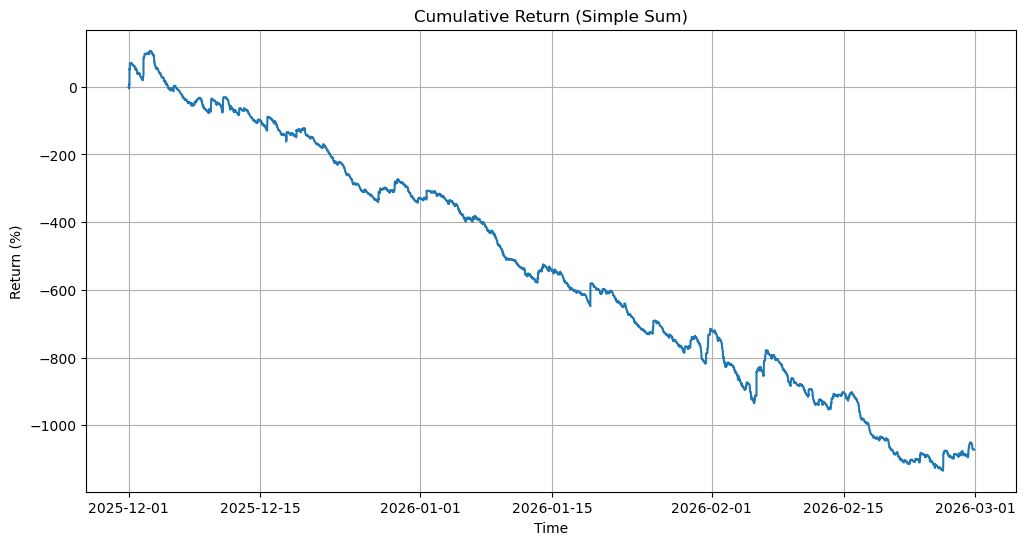

In [105]:
# Trade'leri kronolojik sıraya alıyoruz (zaman serisi analizi için gerekli)
trades = trades.sort_values("entry_time")

# Her trade sonucunu (trade_return_net) toplayıp (kümülatif toplam), elde ettiğimiz performansı görselleştirelim
# Not: Bu yöntem bileşik getiri içermez, gerçek equity eğrisi değildir

trades["cum_return"] = trades["trade_return_net"].cumsum()

# Kümülatif getiri grafiği
plt.figure(figsize=(12,6))
plt.plot(trades["entry_time"], trades["cum_return"])
plt.title("Cumulative Return (Simple Sum)")
plt.xlabel("Time")
plt.ylabel("Return (%)")
plt.grid()
plt.show()

In [106]:
# Yukarıdaki grafik incelendiğinde, stratejinin zaman içerisinde istikrarlı bir şekilde değer kaybettiği görülmektedir.

# Kümülatif getiri eğrisi genel olarak aşağı yönlü bir trend sergilemektedir. Bu durum, ortalama işlem getirisinin negatif olduğunu ve stratejinin sürdürülebilir olmadığını göstermektedir.

# Not: Bu grafik bileşik getiri içermediği için gerçek sermaye büyümesini yansıtmaz ancak stratejinin genel yönünü hızlıca görmek için faydalıdır.

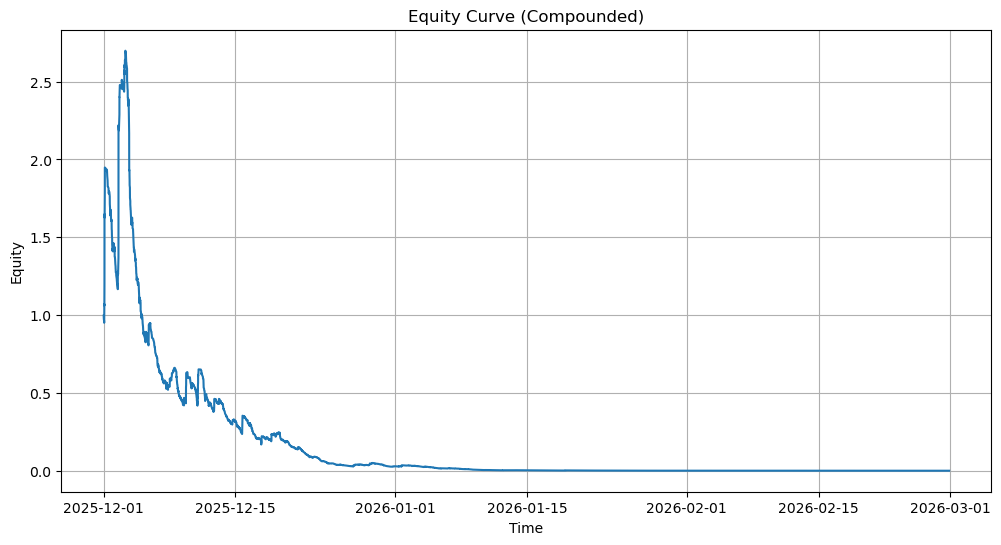

In [107]:
# Gerçekçi equity curve (bileşik getiri)

# Bu adımda, her trade sonrası sermayenin nasıl değiştiğini hesaplıyoruz
# Amaç: Stratejinin gerçek para büyümesini (compounding etkisi ile) simüle etmek

# trade_return_net yüzde olduğu için önce 1 + (return/100) formatına çevirelim
# ardından tüm işlemler çarpılarak kümülatif büyüme hesaplanır

trades["equity"] = (1 + trades["trade_return_net"] / 100).cumprod()

# Bu yöntem:
    # compounding etkisini içerir
    # gerçekçi performans gösterir
    # en doğru backtest metriğidir


# Equity curve grafiği

plt.figure(figsize=(12,6))
plt.plot(trades["entry_time"], trades["equity"])

plt.title("Equity Curve (Compounded)")
plt.xlabel("Time")
plt.ylabel("Equity")

plt.grid()
plt.show()


# Özetle bu bölümde, her işlem sonrası sermayenin bileşik getiri ile nasıl değiştiği hesaplanmış ve stratejinin zaman içerisindeki gerçek performansı görselleştirilmiştir.

In [108]:
# Yukarıdaki Equity eğrisi incelendiğinde, stratejinin başlangıçta kısa süreli bir yükseliş gösterdiği ancak sonrasında hızlı bir şekilde değer kaybettiği görülmektedir.

# Bileşik getiri etkisiyle birlikte sermayenin zamanla ciddi oranda azaldığı ve stratejinin uzun vadede sürdürülebilir olmadığı açıkça görülmektedir.

# Bu sonuç, işlem maliyetlerinin (fee) ve zayıf sinyal kalitesinin performansı önemli ölçüde etkilediğini göstermektedir.

### Sonuç

Bu çalışmada, kripto para piyasasına ait zaman serisi verileri kullanılarak teknik göstergelere dayalı bir işlem stratejisi oluşturulmuş ve geçmiş veriler üzerinde backtest edilmiştir.

Elde edilen sonuçlar incelendiğinde, stratejinin ortalama işlem getirisi negatif, kazanma oranının ise düşük seviyelerde olduğu görülmüştür. Kümülatif getiri ve equity eğrileri de stratejinin zaman içerisinde sürdürülebilir bir performans sergilemediğini açıkça göstermektedir.

Bu sonuç, finansal piyasalarda basit kural setleri ile kalıcı bir “edge” elde etmenin zor olduğunu ortaya koymaktadır. Aynı zamanda, backtest sürecinde gerçekçi fiyat kullanımı (normal_open), işlem maliyetlerinin dahil edilmesi ve veri sızıntısının engellenmesi gibi unsurların sonuçları ciddi şekilde etkilediği gözlemlenmiştir.

Bu çalışma, bir stratejinin yalnızca sinyal üretmekle değil, doğru şekilde test edilmesi gerektiğini göstermektedir. Ayrıca, finansal zaman serileri üzerinde güvenilir bir backtest altyapısının nasıl kurulacağını ve strateji performansının nasıl objektif bir şekilde değerlendirileceğini ortaya koymaktadır.